# Real Estate Investment Prediction — Results & Visualizations

This notebook trains the Logistic Regression and Random Forest classifiers on the
pre-built feature set and produces all evaluation visualizations:
ROC curves, confusion matrices, feature importance, and a geographic breakdown
of predicted high-growth ZIP codes.

**Prerequisite:** run `python data_pipeline.py` first to generate `data/output/train.csv` and `data/output/test.csv`.

## Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from supervised_models import (
    make_logistic_regression,
    make_random_forest,
    ml_feature_columns,
    binary_metrics_dict,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = Path("data/output/train.csv")
TEST_PATH  = Path("data/output/test.csv")

assert TRAIN_PATH.exists(), f"Missing {TRAIN_PATH} — run data_pipeline.py first"
assert TEST_PATH.exists(),  f"Missing {TEST_PATH}  — run data_pipeline.py first"
print("Data files found.")

Data files found.


## Load Data & Train Models

In [2]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH,  low_memory=False)

feat_cols = ml_feature_columns(train)
X_train = train[feat_cols].to_numpy(dtype=np.float64)
X_test  = test[feat_cols].to_numpy(dtype=np.float64)
y_train = train["label"].to_numpy()
y_test  = test["label"].to_numpy()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {len(feat_cols)}")
print(f"Label balance (test) — high-growth: {y_test.mean():.1%}")

Train: (16115, 23) | Test: (4029, 23)
Features: 23
Label balance (test) — high-growth: 27.1%


In [3]:
print("Training Logistic Regression...")
lr = make_logistic_regression()
lr.fit(X_train, y_train)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("Training Random Forest...")
rf = make_random_forest()
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Done.")

Training Logistic Regression...
Training Random Forest...
Done.


## Results Summary

All metrics computed on the held-out 20% test set.

In [4]:
rows = []
for label, pred, proba in [
    ("Logistic Regression", lr_pred, lr_proba),
    ("Random Forest",       rf_pred, rf_proba),
]:
    m = binary_metrics_dict(y_test, pred, proba)
    m["Model"] = label
    rows.append(m)

results_df = pd.DataFrame(rows).set_index("Model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc"]
]
results_df.columns = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
results_df.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.760,0.538,0.797,0.643,0.847
Random Forest,0.796,0.597,0.754,0.667,0.871


## ROC Curves

Both models plotted side-by-side against the random baseline (dashed diagonal). 
Random Forest achieves **0.872 AUC** vs 0.847 for Logistic Regression.

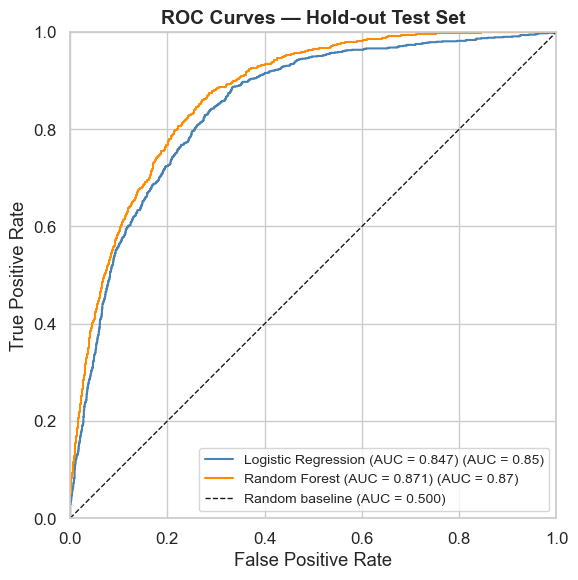

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, lr_proba,
    name=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})",
    ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    y_test, rf_proba,
    name=f"Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})",
    ax=ax, color="darkorange"
)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline (AUC = 0.500)")
ax.set_title("ROC Curves — Hold-out Test Set", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion Matrices

Rows = actual class, columns = predicted class. 
The dataset is imbalanced (~25% positive), so precision/recall matter more than raw accuracy.

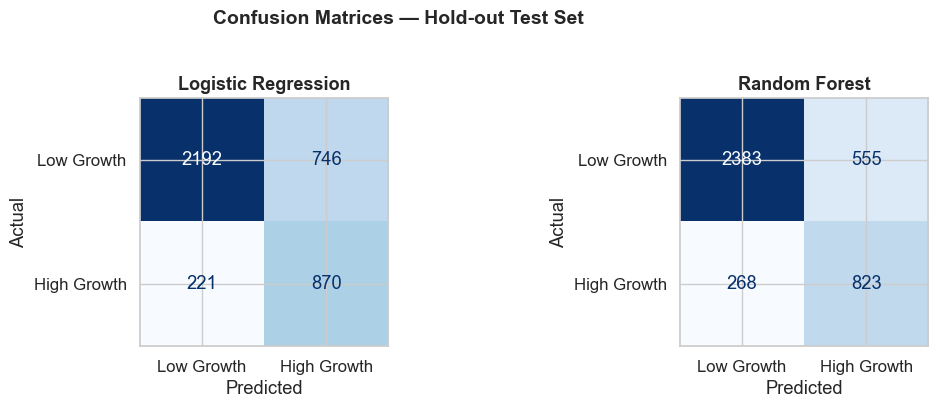

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ["Logistic Regression", "Random Forest"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=["Low Growth", "High Growth"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.images[0].colorbar.remove()

plt.suptitle("Confusion Matrices — Hold-out Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Importance (Random Forest)

Top 20 features by mean decrease in impurity. 
Zillow momentum features (returns, acceleration) dominate, 
with Census demographics providing supplementary signal.

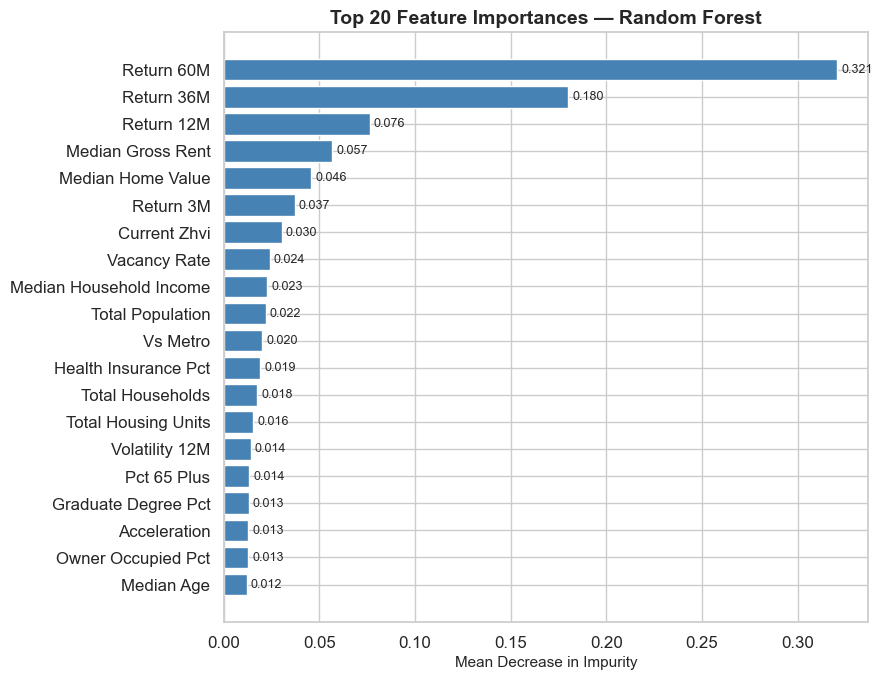

In [7]:
# Random Forest pipeline has no scaler — the classifier is the estimator directly
importances = rf.feature_importances_
feat_imp = (
    pd.Series(importances, index=feat_cols)
    .sort_values(ascending=False)
    .head(20)
)

# Clean up feature names for display
feat_imp.index = feat_imp.index.str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.set_title("Top 20 Feature Importances — Random Forest", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
fig.savefig(PLOTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Predicted High-Growth ZIP Codes by State

States ranked by number of ZIP codes predicted as high-growth by the Random Forest model. 
Captures where the model sees the most concentrated opportunity.

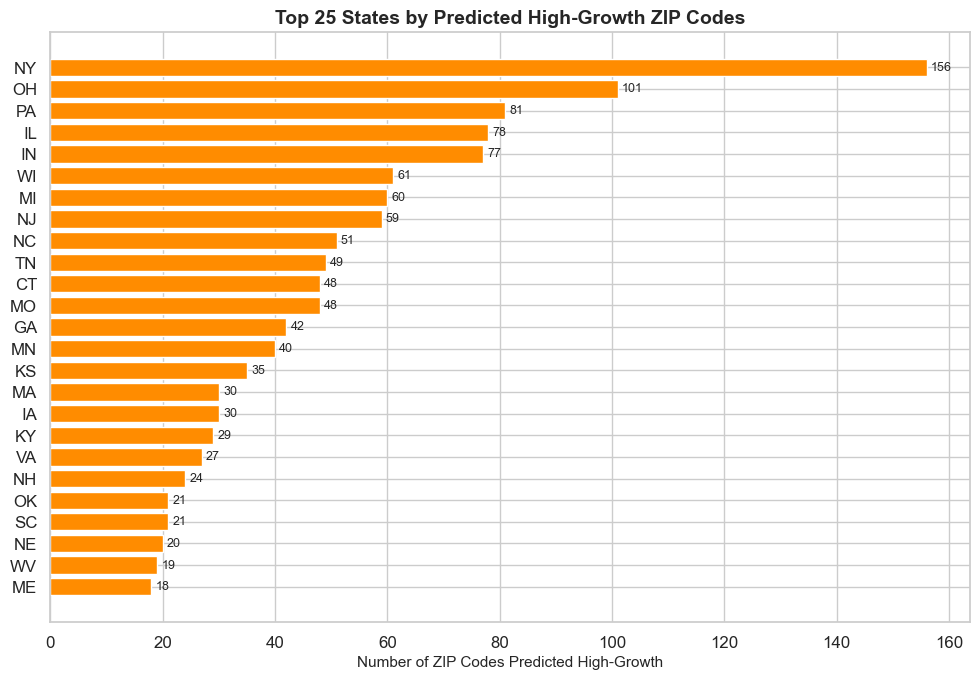

In [8]:
geo_cols = [c for c in ["RegionName", "State", "StateName", "Metro"] if c in test.columns]
geo_df = test[geo_cols].copy()
geo_df["predicted_high_growth"] = rf_pred
geo_df["rf_probability"] = rf_proba

state_counts = (
    geo_df[geo_df["predicted_high_growth"] == 1]
    .groupby("State")
    .size()
    .sort_values(ascending=False)
    .head(25)
    .reset_index(name="predicted_high_growth_zips")
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    state_counts["State"][::-1],
    state_counts["predicted_high_growth_zips"][::-1],
    color="darkorange", edgecolor="white"
)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of ZIP Codes Predicted High-Growth", fontsize=11)
ax.set_title("Top 25 States by Predicted High-Growth ZIP Codes", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "predicted_high_growth_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

## Top Predicted High-Growth ZIP Codes

The 25 ZIP codes with the highest predicted probability of being in the top 25% nationally 
for 1-year home value growth.

In [9]:
top_zips = (
    geo_df[["RegionName", "State", "Metro", "rf_probability"]]
    .sort_values("rf_probability", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
top_zips.index += 1
top_zips.columns = ["ZIP Code", "State", "Metro Area", "Predicted Probability"]
top_zips["Predicted Probability"] = top_zips["Predicted Probability"].round(3)
top_zips

,ZIP Code,State,Metro Area,Predicted Probability
1,49829,MI,"Escanaba, MI",0.962
2,13212,NY,"Syracuse, NY",0.958
3,13080,NY,"Syracuse, NY",0.957
4,27239,NC,"Winston-Salem, NC",0.951
5,13088,NY,"Syracuse, NY",0.949
6,13421,NY,"Syracuse, NY",0.949
7,44864,OH,"Ashland, OH",0.949
8,54124,WI,"Green Bay, WI",0.949
9,61111,IL,"Rockford, IL",0.947
10,54304,WI,"Green Bay, WI",0.947


## Precision–Recall Tradeoff

Since the dataset is imbalanced, the classification threshold of 0.5 isn't necessarily optimal. 
This plot shows how precision and recall change as the decision threshold varies for Random Forest.

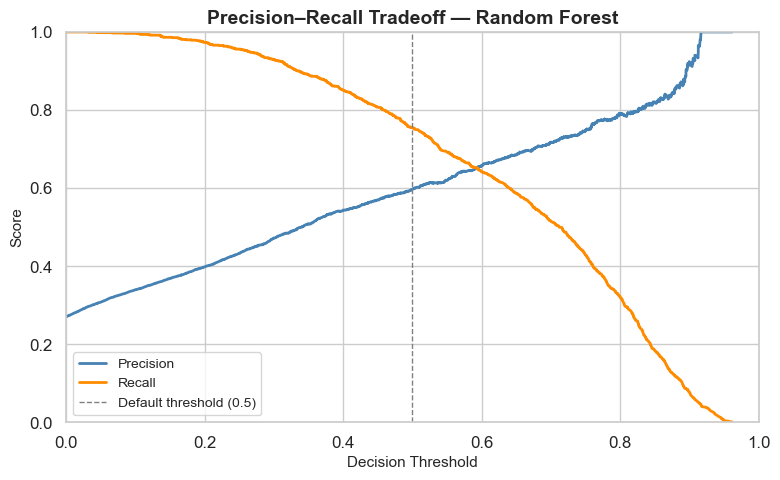

In [10]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_vals[:-1], label="Precision", color="steelblue", linewidth=2)
ax.plot(thresholds, recall_vals[:-1],    label="Recall",    color="darkorange", linewidth=2)

# Mark the default 0.5 threshold
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Default threshold (0.5)")

ax.set_xlabel("Decision Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Precision–Recall Tradeoff — Random Forest", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "precision_recall_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Baseline (demographic index) | 0.559 | 0.161 | 0.149 | 0.154 | — |
| Logistic Regression | 0.760 | 0.538 | 0.797 | 0.643 | 0.847 |
| **Random Forest** | **0.796** | **0.597** | **0.755** | **0.667** | **0.872** |

Key takeaways:
- Zillow momentum features (return windows, acceleration) are the strongest predictors — price history encodes a lot of signal about near-term growth
- Census demographic features add meaningful lift on top of price data alone
- The hand-crafted demographic baseline barely beats random guessing, confirming that naive feature weighting is not a substitute for learning from data
- All plots saved to `plots/`